<a href="https://colab.research.google.com/github/bigdata1210/Tarea_Big_Data/blob/main/Taller_Regresion_Grupo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller de Clase: Regresión con Machine Learning
## Predicción del precio de vivienda por unidad de área (Real Estate Valuation Dataset)

**Integrantes:**
*   **Investigador(a) de métricas:** Mishell Arellano
*   **Encargado(a) de EDA y preprocesamiento:** Roberto Goyes
*   **Encargado(a) de modelado:** Joan Navas
*   **Encargado(a) de evaluación y reporte:** Melany Vera

---

## Fase 1 — Investigación Teórica

### 1. ¿Qué diferencia hay entre un problema de regresión y uno de clasificación?
En clasificación, el objetivo es predecir etiquetas discretas o categorías, por ejemplo, si un cliente pagará o no un crédito. En regresión, buscamos predecir un valor numérico continuo, como el precio de una vivienda.

Las métricas no pueden ser las mismas porque en clasificación medimos aciertos/errores cualitativos (matriz de confusión), mientras que en regresión medimos la distancia o error cuantitativo entre el valor real ($y$) y la predicción del modelo ($\hat{y}$).


### 2. Análisis Detallado de Métricas

*   **MAE (Error Absoluto Medio):**
    *   *Fórmula:* $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
    *   *Qué mide:* La magnitud promedio de los errores en las predicciones, sin importar su dirección (si se quedó corto o se pasó).
    *   *Unidades:* Las mismas de la variable objetivo ($10,000 \text{ NT\$}/\text{Ping}$).
    *   *Cuándo usarla/evitarla:* Conviene usarla cuando se requiere una métrica intuitiva y robusta ante valores atípicos. Se debe evitar si los errores grandes representan un riesgo crítico que deba penalizarse con mayor severidad.

*   **MSE (Error Cuadrático Medio):**
    *   *Fórmula:* $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
    *   *Qué mide:* El promedio de los errores al cuadrado. Al elevar los términos al cuadrado, penaliza de manera exponencial los errores grandes.
    *   *Unidades:* Unidades originales al cuadrado ($(10,000 \text{ NT\$}/\text{Ping})^2$), lo que dificulta su interpretación directa.
    *   *Cuándo usarla/evitarla:* Ideal como función de pérdida para optimizar algoritmos matemáticamente. Evitar al presentar reportes a audiencias no técnicas debido a la distorsión de sus unidades.

*   **RMSE (Raíz del Error Cuadrático Medio):**
    *   *Fórmula:* $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
    *   *Qué mide:* La desviación estándar de los residuos. Mantiene la propiedad del MSE de penalizar los errores grandes, pero devuelve el resultado a la escala original de los datos.
    *   *Unidades:* Las mismas de la variable objetivo ($10,000 \text{ NT\$}/\text{Ping}$).
    *   *Cuándo usarla/evitarla:* Es la métrica estándar en la literatura de Machine Learning cuando los errores grandes son costosos. Evitar si el dataset tiene demasiados outliers que no se quieren priorizar.

*   **MAPE (Error Porcentual Absoluto Medio):**
    *   *Fórmula:* $$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$
    *   *Qué mide:* El error promedio de las predicciones expresado en términos porcentuales relativos a los valores reales.
    *   *Unidades:* Porcentaje ($\%$).
    *   *Cuándo usarla/evitarla:* Excelente para comunicación con áreas administrativas o de negocio ("el modelo se equivoca en promedio un 8%"). Evitar estrictamente si la variable objetivo contiene valores iguales o muy cercanos a cero.

*   **$R^2$ (Coeficiente de Determinación):**
    *   *Fórmula:* $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
    *   *Qué mide:* La proporción de la varianza total de la variable objetivo que es explicada y capturada por las variables independientes del modelo.
    *   *Unidades:* Adimensional (escala de $-\infty$ a $1$).
    *   *Cuándo usarla/evitarla:* Útil para evaluar la bondad de ajuste global de un único modelo. Evitar al comparar modelos que tengan diferente número de variables predictoras.

*   **$R^2$ Ajustado:**
    *   *Fórmula:* $$R^2_{\text{ajustado}} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - p - 1} \right]$$
    *   *Qué mide:* Modifica el $R^2$ introduciendo una penalización por cada variable ($p$) añadida al modelo que no aporte poder predictivo real.
    *   *Unidades:* Adimensional.
    *   *Cuándo usarla/evitarla:* Obligatorio para comparar de forma justa el rendimiento de modelos de regresión lineal múltiple con diferente número de características.

---


### 3. ¿Por qué el $R^2$ por sí solo puede ser engañoso al comparar modelos con distinto número de variables?
El $R^2$ tiene una propiedad matemática por la cual su valor nunca disminuye al agregar nuevas variables al modelo, incluso si estas variables son puro ruido aleatorio o datos irrelevantes (como el ID del registro). Esto puede generar una falsa impresión de mejora y provocar sobreajuste (*overfitting*). Por ello, al comparar modelos con diferente número de variables, se debe usar el $R^2$ Ajustado, el cual penaliza la complejidad innecesaria.

### 4. ¿Qué ventaja tiene el RMSE sobre el MAE cuando existen valores atípicos (outliers)? ¿Y qué ventaja tiene el MAE sobre el RMSE?
*   **Ventaja de RMSE sobre MAE:** Al elevar los errores al cuadrado, el RMSE magnifica los errores grandes. Si el modelo comete un error grave en una predicción, el RMSE aumentará drásticamente. Esto es una ventaja si el objetivo del negocio es obligar al modelo a corregir y evitar errores grandes a toda costa.
*   **Ventaja de MAE sobre RMSE:** El MAE es una métrica lineal donde cada error pesa proporcionalmente a su magnitud absoluta. Si el dataset tiene valores atípicos que representan anomalías ruidosas o inevitables que no se desean priorizar, el MAE ofrece una visión más estable y realista del error "típico" del modelo sin verse distorsionado por los extremos.

---

### 5. Tabla Resumen de Métricas

| Métrica | Fórmula | Interpretación | Cuándo usarla |
| :--- | :--- | :--- | :--- |
| **MAE** | $\frac{1}{n} \sum \|y_i - \hat{y}_i\|$ | Magnitud promedio del error en unidades reales. | Cuando se busca robustez ante atípicos e interpretación simple. |
| **MSE** | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | Promedio de errores al cuadrado. | Principalmente como función de optimización matemática. |
| **RMSE** | $\sqrt{\text{MSE}}$ | Desviación estándar de los errores en unidades reales. | Cuando los errores grandes son inaceptables o muy costosos. |
| **MAPE** | $\frac{100\%}{n} \sum \|\frac{y_i - \hat{y}_i}{y_i}\|$ | Error relativo expresado en porcentaje. | Para presentar resultados de forma intuitiva a la gerencia. |
| **$R^2$** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proporción de la varianza explicada por el modelo. | Para evaluar el ajuste general de un modelo individual. |
| **$R^2$ Ajustado** | $1 - \frac{(1-R^2)(n-1)}{n-p-1}$ | Varianza explicada penalizando el exceso de variables. | Al comparar modelos con diferente cantidad de variables independientes. |

---

### Referencias Bibliográficas
1. Scikit-learn documentation. *Regression metrics*. Recuperado de https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*. Springer.

# Fase 2 — Implementación

En esta sección se desarrolla el flujo completo de Ciencia de Datos aplicado a un problema de regresión. Se abarcará la carga de datos, el análisis exploratorio (EDA), el preprocesamiento formal mediante escalado, la partición de conjuntos, el entrenamiento de tres algoritmos de Machine Learning y la evaluación comparativa de sus métricas diagnósticas.


## 2.1 Carga y Exploración de Datos (EDA)
En esta sección realizaremos la auditoría inicial de los datos para entender sus dimensiones, tipos de variables, presencia de nulos y relaciones estadísticas antes de construir los modelos predictivos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de diseño para que los gráficos del informe se vean limpios
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga automática del dataset de Real Estate de Taiwán (UCI ML Repository)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00477/Real%20estate%20valuation%20data%20set.xlsx"
df = pd.read_excel(url)

# Imprimir dimensiones solicitadas por la rúbrica
print(f"Dimensiones del dataset: {df.shape[0]} registros (filas) y {df.shape[1]} variables (columnas).")

Dimensiones del dataset: 414 registros (filas) y 8 variables (columnas).


In [ ]:
print("--- Tipos de Datos e Inspección de Nulos ---")
print(df.info())

print("\n--- Verificación de Registros Duplicados ---")
print(f"Cantidad de filas duplicadas detectadas: {df.duplicated().sum()}")

--- Tipos de Datos e Inspección de Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB
None

--- Verificación de Registros Duplicados ---
Cantidad de filas duplicadas detectadas: 0


In [ ]:
# .describe() genera automáticamente media, desviación estándar (std), mínimos y máximos.
resumen_estadistico = df.describe()
resumen_estadistico

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


> **Nota de Análisis sobre Rangos y Desviaciones:**
> Al observar la tabla descriptiva, se evidencia que las variables operan en escalas drásticamente opuestas. Por ejemplo, la antigüedad de la vivienda (`X2 house age`) varía en un rango de 0 a 43.8 años, mientras que la distancia al metro (`X3 distance to the nearest MRT station`) presenta un rango masivo que va desde los 23.3 metros hasta los 6,485.5 metros. Esta disparidad extrema de magnitudes justifica metodológicamente la necesidad de aplicar un escalado de datos más adelante.

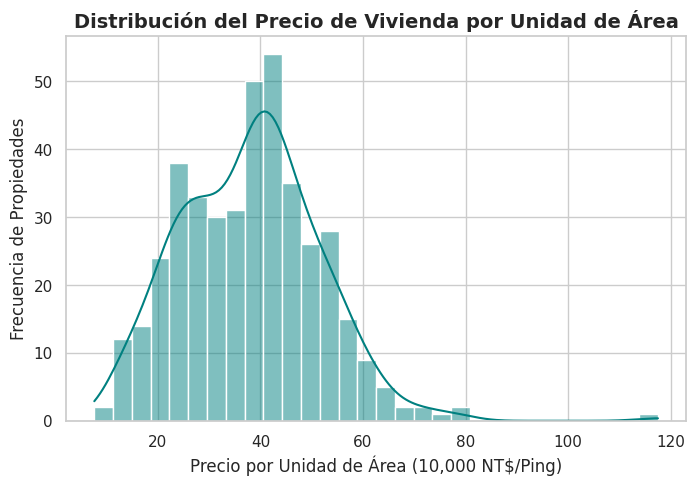

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Y house price of unit area'], kde=True, color='teal', bins=30)
plt.title('Distribución del Precio de Vivienda por Unidad de Área', fontsize=14, fontweight='bold')
plt.xlabel('Precio por Unidad de Área (10,000 NT$/Ping)')
plt.ylabel('Frecuencia de Propiedades')
plt.show()

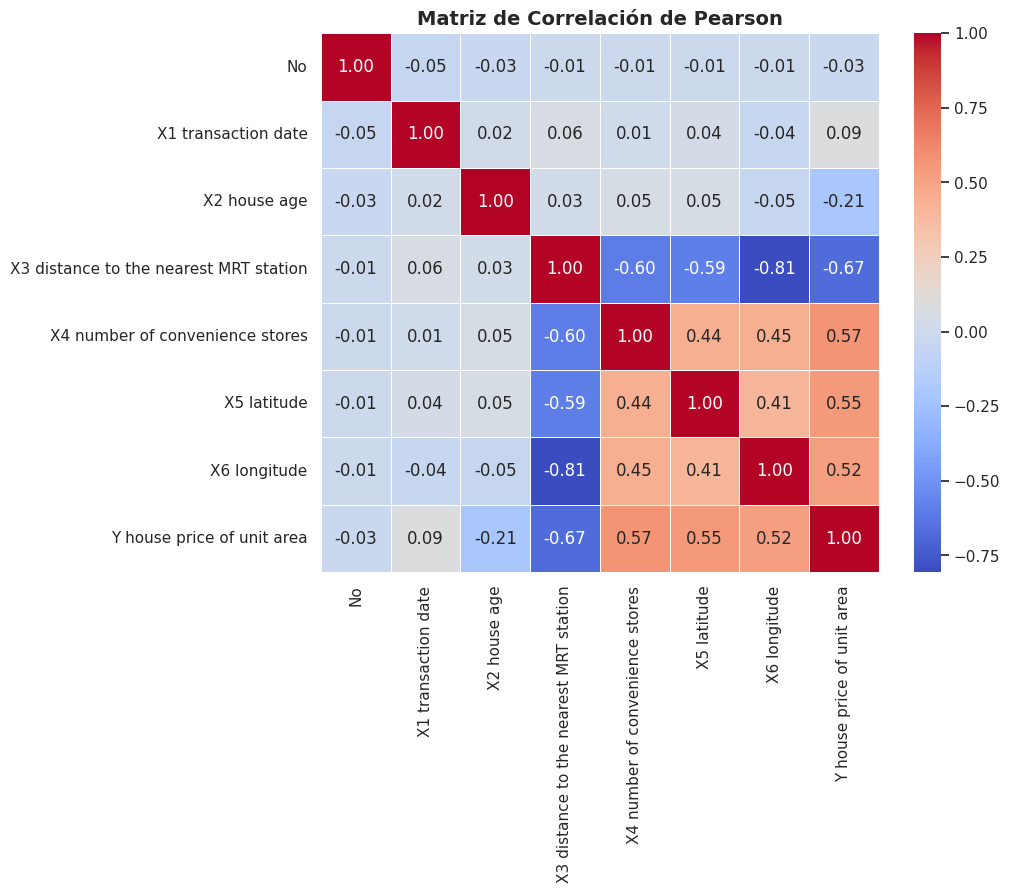

In [ ]:
plt.figure(figsize=(9, 7))
matriz_corr = df.corr()

# Creamos el mapa de calor con anotaciones numéricas de los coeficientes
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Pearson', fontsize=14, fontweight='bold')
plt.show()

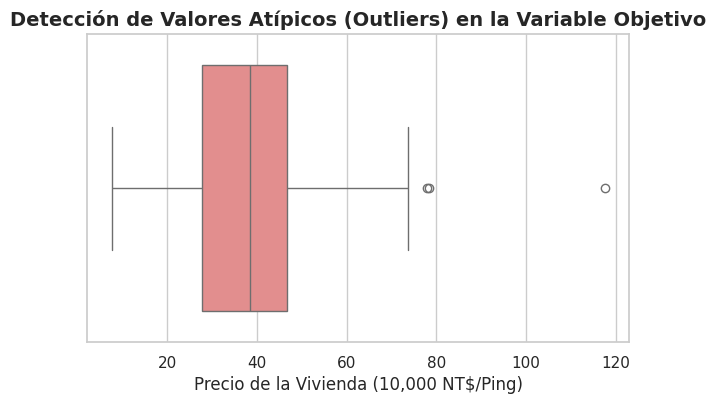

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df['Y house price of unit area'], color='lightcoral')
plt.title('Detección de Valores Atípicos (Outliers) en la Variable Objetivo', fontsize=14, fontweight='bold')
plt.xlabel('Precio de la Vivienda (10,000 NT$/Ping)')
plt.show()

### Justificación del Tratamiento de Outliers
Al inspeccionar el diagrama de caja (boxplot), se observa la presencia de un par de propiedades con un precio por unidad de área superior a 100 (llegando a un extremo cercano a 120).

**Decisión del grupo:** Se determina conservar estos registros en el dataset debido a que el tamaño de la muestra es pequeño (414 registros) y estos valores representan transacciones reales de un mercado inmobiliario de alta gama en Taiwán, no errores de digitación. No obstante, se priorizará el uso de algoritmos basados en árboles (como Random Forest) en la siguiente etapa, dado que estos modelos manejan de forma natural y robusta la presencia de estos valores extremos sin distorsionar sus predicciones.

## 2.2 Preprocesamiento de Datos
En esta sección se ejecutan las transformaciones técnicas necesarias para estructurar los datos de manera óptima antes del proceso de modelado matemático.

In [ ]:
# Eliminación segura de la columna de identificación secuencial
if 'No' in df.columns:
    df = df.drop(columns=['No'])

# Separación en X (variables predictoras) y y (variable objetivo)
X = df.drop(columns=['Y house price of unit area'])
y = df['Y house price of unit area']

print("Variables predictoras seleccionadas para el entrenamiento (X):")
print(list(X.columns))

Variables predictoras seleccionadas para el entrenamiento (X):
['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']


In [ ]:
from sklearn.model_selection import train_test_split

# Partición formal: 80% entrenamiento para ajustar el modelo, 20% prueba para evaluarlo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Registros destinados a Entrenamiento (Train): {X_train.shape[0]}")
print(f"Registros destinados a Examen Final (Test): {X_test.shape[0]}")

Registros destinados a Entrenamiento (Train): 331
Registros destinados a Examen Final (Test): 83


In [ ]:
from sklearn.preprocessing import StandardScaler

# Inicialización del estandarizador (media = 0, varianza = 1)
scaler = StandardScaler()

# ¡CRUCIAL!: Ajustamos parámetros usando únicamente Train, y transformamos ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡Estandarización completada con éxito!")
print("Los arreglos 'X_train_scaled' y 'X_test_scaled' están listos en la memoria para alimentar los algoritmos.")

¡Estandarización completada con éxito!
Los arreglos 'X_train_scaled' y 'X_test_scaled' están listos en la memoria para alimentar los algoritmos.
